
## Flajolet-Martin and Count-Min Sketch

This notebook implements and experiments with:
- **FM** (Flajolet-Martin) distinct counting, in three versions:
  - Regular
  - Beta / Average-of-Minima
  - Median-of-Betas
- **CMS** (Count-Min Sketch) frequency estimation

**Requirements satisfied:**
- Stream size **≥ 100,000**
- Number of unique elements **≥ 10,000**
- **50 trials** per estimator configuration
- Multiple sketch sizes
- Constant random seed for reproducible results
- Plots: accuracy, bias, normalized variance vs sketch size
- Theory: compute **epsilon** and **delta** for 95% success probability
- Memory + runtime discussion and proxies
- Analysis & conclusions

**Extras:**
- Plots: convergence over time (prefix length)
- Runtime/duration logs

---

## 0) Setup

We install and import required packages.  
We also set a constant global seed for reproducible results.

In [ ]:
# install huggingface datasets for loading an existing dataset
!pip -q install datasets

# import warnings for suppressing non-critical dataset auth warnings
import warnings
# ignore the huggingface token warning for public datasets
warnings.filterwarnings("ignore", message="The secret `HF_TOKEN` does not exist*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import string
from typing import Tuple, List
from datasets import load_dataset

# set a global seed for reproducibility
GLOBAL_SEED = 12345
np.random.seed(GLOBAL_SEED)

## 1) Build a Data Stream From an Existing Dataset

We use **WikiText-2-raw** (train split) and build a token stream.

Preprocessing:
- Lowercase
- Strip leading/trailing punctuation
- Remove empty tokens

We then map tokens to integer IDs for fast hashing/sketch operations.

Constraints checked:
- `N >= 100000`
- `F0 >= 10000`

### We Evaluate CMS on **Heavy Hitters (HH)** and **Tail**:

### Motivation: CMS Has an **Additive** Error Guarantee
Count-Min Sketch (CMS) estimates frequencies using:
$$
\tilde f_x = \min_{i \in \{1,\dots,d\}} C_i[h_i(x)]
$$
Because collisions only **increase** counters, CMS satisfies:
$$
\tilde f_x \ge f_x \quad \text{(never underestimates)}
$$
And with probability at least $1-\delta$:
$$
\tilde f_x \le f_x + \epsilon F_1
$$
where $F_1 = \sum_x f_x$ is the total stream length.

This guarantee is **additive** ($+\epsilon F_1$), not relative.  
So the *same* additive error has very different impact depending on whether $f_x$ is large or small.

---

### Why Split Into HH vs Tail?
We evaluate two representative regimes:

#### 1) Heavy Hitters (HH): “Large” $f_x$
Define HH as the top-$K$ items by true frequency:
$$
HH = \{x_1,\dots,x_K\} \quad \text{such that } f_{x_1}\ge f_{x_2}\ge \dots \ge f_{x_K}
$$
For heavy hitters, $f_x$ is large, so even if the additive error is up to $\epsilon F_1$, the **relative** error is often moderate:
$$
\frac{\tilde f_x - f_x}{f_x} \le \frac{\epsilon F_1}{f_x}
\quad \text{(smaller when } f_x \text{ is large)}
$$
**Interpretation:** HH tests whether CMS is useful for “important / frequent” keys.

#### 2) Tail: “Small” $f_x$
Define Tail by sampling $K$ items uniformly from the remaining distinct keys (excluding HH):
$$
TAIL \subseteq \{x: x \notin HH\}, \quad |TAIL|=K
$$
Tail items have small $f_x$ (often near 1–10 in natural language streams), so the **same** additive error yields huge relative error:
$$
\frac{\tilde f_x - f_x}{f_x} \le \frac{\epsilon F_1}{f_x}
\quad \text{(can be very large when } f_x \text{ is small)}
$$
**Interpretation:** Tail tests the “hard case” where CMS is not designed to give uniform relative accuracy.

---

### Evaluation Procedure (Per Trial, Per Sketch Size)
For each trial and each CMS width $w$ (with fixed depth $d$):

1. Build CMS from the stream.
2. Query frequencies for:
   - HH set (top-$K$ keys by exact counts)
   - Tail set ($K$ random non-HH keys)
3. Compute metrics **separately** for HH and Tail (two curves per metric).

This produces two curves because CMS behaves differently in these two regimes.

---

### Why This Design Is Informative
- It directly matches CMS theory:
  - **Always overestimates**: $\tilde f_x \ge f_x$ (sanity check verifies this).
  - **Additive bound**: $\tilde f_x \le f_x + \epsilon F_1$ w.p. $\ge 1-\delta$.
- It avoids misleading “averages” across mixed-frequency keys:
  - Mixing HH and Tail would hide the fact that relative error can be small for HH but huge for Tail.
- It gives clean, interpretable plots:
  - HH curves show “practical usefulness” for frequent items.
  - Tail curves show the expected weakness of additive-only guarantees.

---

### What We Expect to See (And Why)
As $w$ increases, $\epsilon$ decreases (roughly $\epsilon \propto 1/w$), so collisions drop:
- Bias decreases for both HH and Tail.
- HH mean ARE usually decreases smoothly.
- Tail mean ARE can remain large unless $w$ is very large, because many tail items have small $f_x$ and $\epsilon F_1/f_x$ stays big.


In [ ]:
# define punctuation characters to strip at token edges
PUNCT = string.punctuation

# define a function to preprocess a single token
def preprocess_token(tok: str) -> str:
    # strip whitespace and lowercase the token
    tok = tok.strip().lower()
    # strip leading and trailing punctuation only
    tok = tok.strip(PUNCT)
    # return the cleaned token
    return tok

# define a function that loads wikitext and builds a token stream meeting constraints
def build_stream_from_wikitext(min_n: int = 100_000, min_f0: int = 10_000, max_n: int = 300_000) -> List[str]:
    # load the wikitext dataset split
    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
    # extract the text column
    texts = ds["text"]
    # initialize the output token list
    tokens: List[str] = []
    # initialize a set to track distinct tokens during streaming
    seen = set()
    # iterate over lines in the dataset
    for line in texts:
        # split each line by whitespace into raw tokens
        for raw in line.split():
            # preprocess the raw token
            tok = preprocess_token(raw)
            # skip empty tokens
            if not tok:
                continue
            # append token to stream
            tokens.append(tok)
            # add token to distinct set
            seen.add(tok)
            # stop once constraints are met
            if len(tokens) >= min_n and len(seen) >= min_f0:
                return tokens
            # stop if we reach the hard cap
            if len(tokens) >= max_n:
                return tokens
    # return collected tokens if dataset ends early
    return tokens

# build the token stream
stream_tokens = build_stream_from_wikitext()

# compute stream length
N = len(stream_tokens)
# compute sorted list of distinct tokens
unique_tokens = sorted(set(stream_tokens))
# compute exact distinct count f0
F0 = len(unique_tokens)

# print stream size and distinct count
print(f"n = {N:,}  f0 = {F0:,}")

# enforce stream size constraint
assert N >= 100_000, "stream length must be at least 100,000"
# enforce distinct constraint
assert F0 >= 10_000, "number of unique elements must be at least 10,000"

# build a mapping from token to integer id
token_to_id = {tok: i for i, tok in enumerate(unique_tokens)}
# convert token stream into an integer id stream
stream_ids = np.fromiter((token_to_id[t] for t in stream_tokens), dtype=np.int64, count=N)

# compute exact frequency vector for ground truth
freq = np.bincount(stream_ids, minlength=F0).astype(np.int64)
# compute f1 which equals n for a pure token stream
F1 = int(freq.sum())

# print f1 sanity check
print(f"f1 = {F1:,} (should equal n)")
# assert f1 equals n
assert F1 == N, "f1 must equal n for this stream"

# set query set size for cms evaluation
K = 200
# create a fixed rng to select the tail query set reproducibly
rng_fixed = np.random.default_rng(GLOBAL_SEED)

# compute ids of the top-k most frequent items
topk_ids = np.argsort(freq)[::-1][:K].astype(np.int64)
# create a pool of ids with positive frequency
tail_pool = np.where(freq > 0)[0]
# remove heavy hitters from the tail pool
tail_pool = np.setdiff1d(tail_pool, topk_ids, assume_unique=False)
# sample k tail ids uniformly without replacement
tail_ids = rng_fixed.choice(tail_pool, size=K, replace=False).astype(np.int64)

# collect true frequencies for heavy hitters (as floats for division)
topk_true = freq[topk_ids].astype(np.float64)
# collect true frequencies for tail items (as floats for division)
tail_true = freq[tail_ids].astype(np.float64)

# print top-5 heavy hitters for sanity
print("top-5 heavy hitters (token, freq):")
# loop over top 5 ids
for i in range(5):
    # get token id
    tid = int(topk_ids[i])
    # get token string
    tok = unique_tokens[tid]
    # print token and frequency
    print((tok, int(freq[tid])))

n = 100,000  f0 = 12,643
f1 = 100,000 (should equal n)
top-5 heavy hitters (token, freq):
('the', 7548)
('of', 3364)
('and', 2974)
('in', 2574)
('to', 2198)


## 2) Convergence Checkpoints (Prefix Lengths)

We interpret “time” as the number of stream items processed (prefix length).

We compute true `F0` at checkpoints for FM convergence plots.

In [ ]:
# define convergence checkpoints (prefix lengths)
CHECKPOINTS = [1_000, 2_000, 5_000, 10_000, 20_000, 30_000, 50_000, 70_000, 100_000]
# keep only checkpoints that are within stream length
CHECKPOINTS = [c for c in CHECKPOINTS if c <= len(stream_ids)]
# print checkpoints
print("checkpoints:", CHECKPOINTS)

# define a function that computes true distinct counts at checkpoints
def true_f0_over_time(stream_ids_arr: np.ndarray, checkpoints: List[int]) -> np.ndarray:
    # allocate seen array for all ids
    seen = np.zeros(int(stream_ids_arr.max()) + 1, dtype=bool)
    # initialize output list of distinct counts
    distinct_counts = []
    # initialize running distinct counter
    distinct = 0
    # track previous checkpoint boundary
    prev = 0
    # iterate over checkpoints
    for cp in checkpoints:
        # take the segment between prev and cp
        seg = stream_ids_arr[prev:cp]
        # keep ids not seen yet
        new = seg[~seen[seg]]
        # update seen/distinct if new ids exist
        if new.size:
            # compute unique new ids
            u = np.unique(new)
            # mark new ids as seen
            seen[u] = True
            # increment distinct by number of new ids
            distinct += u.size
        # append the running distinct count
        distinct_counts.append(distinct)
        # advance prev
        prev = cp
    # return distinct counts as numpy array
    return np.array(distinct_counts, dtype=np.int64)

# compute true f0 over time
true_F0_t = true_f0_over_time(stream_ids, CHECKPOINTS)
# print the true f0 series
print("true f0 at checkpoints:", true_F0_t.tolist())

checkpoints: [1000, 2000, 5000, 10000, 20000, 30000, 50000, 70000, 100000]
true f0 at checkpoints: [473, 761, 1569, 2652, 4377, 5850, 8055, 10216, 12643]


## 3) Hashing Utilities (Reproducible)

We avoid Python’s built-in `hash()` because it can vary per session.

We use a fast 64-bit hash family:
- `h(x) = a*x + b (mod 2^64)` with `a` forced odd

We convert 64-bit hashes to uniform floats `u in [0,1)` via `u = h / 2^64`.

In [ ]:
# define 2^64 as a float for normalization to [0,1)
TWO64 = float(2**64)

# define a function that generates hash parameters a and b
def gen_ab(rng: np.random.Generator, size: int) -> Tuple[np.ndarray, np.ndarray]:
    # sample random 64-bit multipliers
    a = rng.integers(1, 2**64, size=size, dtype=np.uint64)
    # force multipliers to be odd to improve mixing
    a |= np.uint64(1)
    # sample random 64-bit offsets
    b = rng.integers(0, 2**64, size=size, dtype=np.uint64)
    # return (a,b) arrays
    return a, b

## 4) Implement FM (Min-Hash) - 3 Versions

We implement the min-hash FM variant from the lecture slides:
- For each hash function, keep the minimum `x = min(h(u))` over distinct elements
- Regular estimate: `(1/x) - 1`
- Beta estimate: use `s` hash functions, average minima `z`, estimate `(1/z) - 1`
- Median-of-betas: build `t` beta estimators (each has `s` minima), output the median

Note: FM distinct counting depends only on the set of distinct IDs, not on frequencies.

In [ ]:
# define a helper that computes minima across distinct ids for multiple hash functions
def fm_minima_over_ids(stream_ids: np.ndarray, a: np.ndarray, b: np.ndarray, chunk_size: int = 4096) -> np.ndarray:
    # convert ids to uint64 for hashing arithmetic
    x = stream_ids.astype(np.uint64)
    # get number of hash functions
    m = int(a.shape[0])
    # initialize minima to 1.0 for each hash function
    minima = np.ones(m, dtype=np.float64)
    # iterate over chunks to limit peak memory
    for start in range(0, x.shape[0], chunk_size):
        # take a chunk of ids
        chunk = x[start:start + chunk_size]
        # compute 64-bit hashes for all ids and all hash functions
        h = (chunk[:, None] * a[None, :] + b[None, :]).astype(np.uint64)
        # convert hashes to uniform floats in [0,1)
        u = h.astype(np.float64) / TWO64
        # compute minima per hash function inside the chunk
        chunk_min = u.min(axis=0)
        # update global minima
        minima = np.minimum(minima, chunk_min)
    # clamp minima away from zero for numerical stability
    minima = np.maximum(minima, np.finfo(np.float64).tiny)
    # return minima vector
    return minima

# define regular fm using one minimum register
def fm_regular(stream_ids: np.ndarray, rng: np.random.Generator) -> float:
    # generate one hash function
    a, b = gen_ab(rng, 1)
    # compute minimum over distinct ids
    mins = fm_minima_over_ids(stream_ids, a, b)
    # extract the single minimum
    x = float(mins[0])
    # return the regular estimator
    return (1.0 / x) - 1.0

# define beta fm using s minima averaged
def fm_beta(stream_ids: np.ndarray, rng: np.random.Generator, s: int) -> float:
    # generate s independent hash functions
    a, b = gen_ab(rng, s)
    # compute minima for each hash function
    mins = fm_minima_over_ids(stream_ids, a, b)
    # compute the average minimum
    z = float(mins.mean())
    # return the beta estimator
    return (1.0 / z) - 1.0

# define median-of-betas fm using t groups of size s
def fm_median_of_betas(stream_ids: np.ndarray, rng: np.random.Generator, t: int, s: int) -> float:
    # generate t*s independent hash functions
    a, b = gen_ab(rng, t * s)
    # compute minima for all hash functions
    mins = fm_minima_over_ids(stream_ids, a, b)
    # reshape minima into t groups each of size s
    mins = mins.reshape(t, s)
    # compute average minimum per group
    z = mins.mean(axis=1)
    # compute one beta estimate per group
    ests = (1.0 / z) - 1.0
    # return the median estimate
    return float(np.median(ests))

## 5) Implement Count-Min Sketch (CMS)

CMS maintains a `d x w` table of counters.  
Update: for each stream element, increment one counter per row.  
Query: return the minimum count across rows.

**Efficiency trick:**  
- CMS Folding (High-Bit Indexing)

We also add a **sanity check** cell later:
- `CMS_est(x) >= true_f(x)` for heavy hitters

### CMS Folding Trick (**High-Bit Indexing**)

### Why We Use Folding
We want to evaluate CMS performance for multiple widths:
$$
w \in \{256,512,1024,2048,4096\}
$$
Naively, we would rebuild a separate CMS for each $w$, which multiplies the build cost by the number of widths.  
Instead, we **build once** at the largest width $w_{\max}=4096$ and derive smaller widths by **folding**. This makes the experiment much faster while keeping comparisons across widths consistent.

---

### Our Indexing Choice: **Take the Top Bits**
In our latest solution we map a 64-bit hash value $h$ to a bucket in $[0,w)$ using the **top** $k$ bits, where $k=\log_2(w)$:
$$
k = \log_2(w), \qquad \text{idx} = \left\lfloor \frac{h}{2^{64-k}} \right\rfloor
$$
In code (for $w_{\max}$):
- we compute $k_{\max}=\log_2(w_{\max})$
- then:
$$
\text{idx}_{\max} = h \gg (64-k_{\max})
$$

This “multiply-shift” style indexing is important because it makes the bucket mapping depend properly on the random hash, so different trials produce different collision patterns (non-zero variance across trials).

---

### What Folding Means Under High-Bit Indexing
Let $w_{\max} = w \cdot \text{factor}$, where:
$$
\text{factor} = \frac{w_{\max}}{w}
$$

Under **high-bit indexing**, going from $w_{\max}$ to a smaller width $w$ means we keep **fewer top bits**, which merges *contiguous ranges* of $w_{\max}$ buckets.

Concretely, bucket $j$ at width $w$ corresponds to the following contiguous block at width $w_{\max}$:
$$
\{\, j\cdot \text{factor},\ j\cdot \text{factor}+1,\ \dots,\ (j+1)\cdot \text{factor}-1 \,\}
$$
So the folded counter is:
$$
C^{(w)}[j] \;=\; \sum_{r=0}^{\text{factor}-1} C^{(w_{\max})}[j\cdot \text{factor} + r]
$$

---

### How We Implement Folding
We fold one max-width row `counts_max_row` (length $w_{\max}$) to width $w$ by reshaping into $w$ blocks of length `factor`, then summing within each block:

- reshape shape: $(w, \text{factor})$
- sum along the second axis


In [ ]:
# define a function that builds cms counters at a maximum width w_max
def cms_build_counts_maxw(stream_ids_arr: np.ndarray, rng: np.random.Generator, d: int, w_max: int = 4096) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # assert w_max is a power of two (required for bitmask modulo)
    assert (w_max & (w_max - 1)) == 0, "w_max must be a power of two"
    # convert stream ids to uint64 for hashing arithmetic
    x = stream_ids_arr.astype(np.uint64)
    # generate d independent hash functions
    a_rows, b_rows = gen_ab(rng, d)
    # allocate the max-width count table
    counts_max = np.zeros((d, w_max), dtype=np.int64)
    # create a bitmask for modulo w_max
    # mask = np.uint64(w_max - 1)
    # iterate over rows
    for i in range(d):
        # hash all stream items for row i
        h = (x * a_rows[i] + b_rows[i]).astype(np.uint64)
        # # map hashes to indices in [0, w_max)
        k_max = int(np.log2(w_max))
        idx = (h >> np.uint64(64 - k_max)).astype(np.int64)
        # fill the row using bincount
        counts_max[i] = np.bincount(idx, minlength=w_max)
    # return hash params and max-width counts
    return a_rows, b_rows, counts_max


def cms_fold_counts(counts_max_row: np.ndarray, w: int) -> np.ndarray:
    # get the max width
    w_max = int(counts_max_row.shape[0])
    assert w_max % w == 0
    factor = w_max // w
    return counts_max_row.reshape(w, factor).sum(axis=1)


# define a function that queries cms estimates for a set of ids using folded counts
def cms_query_from_max(counts_max: np.ndarray, a_rows: np.ndarray, b_rows: np.ndarray, query_ids_arr: np.ndarray, w: int) -> np.ndarray:
    # read depth and max width from counts array
    d, w_max = counts_max.shape
    # assert w is a power of two and not larger than w_max
    assert (w & (w - 1)) == 0 and w <= w_max
    # fold each row down to width w
    folded = np.stack([cms_fold_counts(counts_max[i], w) for i in range(d)], axis=0)
    # convert query ids to uint64 for hashing arithmetic
    q = query_ids_arr.astype(np.uint64)
    # create a bitmask for modulo w
    # mask = np.uint64(w - 1)
    # collect per-row estimates in a list
    ests = []
    # iterate over rows
    for i in range(d):
        # hash query ids for row i
        hq = (q * a_rows[i] + b_rows[i]).astype(np.uint64)
        # map hashes to indices in [0, w)
        k = int(np.log2(w))
        idx = (hq >> np.uint64(64 - k)).astype(np.int64)
        # gather counts for those indices
        ests.append(folded[i, idx])
    # stack row estimates into shape (d, n_queries)
    ests = np.stack(ests, axis=0)
    # return min across rows (cms query rule)
    return ests.min(axis=0)

## 6) Experiment Configuration

We run 50 trials.

FM sizes:
- Regular: 1 register
- Beta: `s` in `{4, 8, 16, 24, 32}`
- Median-of-betas: fixed `t = 36`, same `s` list

CMS sizes:
- Depth `d = 5` (gives $\delta = 2^{-5} = 0.03125$, i.e., ≥95% success probability)
- Width `w` in `{256, 512, 1024, 2048, 4096}`

In [ ]:
# set number of trials for statistical significance
TRIALS = 50

# define fm s values for beta and median versions
FM_SIZES = [4, 8, 16, 24, 32]
# set t for median-of-betas
FM_T = 36

# set cms depth
CMS_D = 5
# define cms widths to sweep
CMS_WIDTHS = [256, 512, 1024, 2048, 4096]
# define cms maximum width for folding trick
CMS_W_MAX = 4096

# compute the set of unique ids for fm
unique_ids_full = np.unique(stream_ids).astype(np.int64)
# assert unique id count matches f0
assert unique_ids_full.size == F0

# print configuration summary
print("trials:", TRIALS)
print("fm sizes (s):", FM_SIZES, "t:", FM_T)
print("cms widths:", CMS_WIDTHS, "d:", CMS_D)

trials: 50
fm sizes (s): [4, 8, 16, 24, 32] t: 36
cms widths: [256, 512, 1024, 2048, 4096] d: 5


## 7) Run Experiments (50 Trials)

We collect:
- FM estimates (regular, beta for each `s`, median-of-betas for each `s`)
- CMS estimates for heavy hitters and tail sets for each width
- Rough runtimes using `time.perf_counter()`

Note:
- For each trial we use a deterministic seed: `GLOBAL_SEED + 10000 + r`

In [ ]:
# allocate storage for fm regular estimates
fm_regular_est = np.zeros(TRIALS, dtype=np.float64)
# allocate storage for fm beta estimates (trials x sizes)
fm_beta_est = np.zeros((TRIALS, len(FM_SIZES)), dtype=np.float64)
# allocate storage for fm median estimates (trials x sizes)
fm_median_est = np.zeros((TRIALS, len(FM_SIZES)), dtype=np.float64)

# allocate storage for cms estimates on heavy hitters (trials x widths x k)
cms_hh_est = np.zeros((TRIALS, len(CMS_WIDTHS), K), dtype=np.int64)
# allocate storage for cms estimates on tail items (trials x widths x k)
cms_tail_est = np.zeros((TRIALS, len(CMS_WIDTHS), K), dtype=np.int64)

# allocate runtime logs for fm regular
rt_fm_regular = np.zeros(TRIALS, dtype=np.float64)
# allocate runtime logs for fm beta (trials x sizes)
rt_fm_beta = np.zeros((TRIALS, len(FM_SIZES)), dtype=np.float64)
# allocate runtime logs for fm median (trials x sizes)
rt_fm_median = np.zeros((TRIALS, len(FM_SIZES)), dtype=np.float64)

# allocate runtime logs for cms build per trial
rt_cms_build = np.zeros(TRIALS, dtype=np.float64)
# allocate runtime logs for cms query per (trial x width)
rt_cms_query = np.zeros((TRIALS, len(CMS_WIDTHS)), dtype=np.float64)

# run repeated trials
for r in range(TRIALS):
    # create a per-trial rng
    rng = np.random.default_rng(GLOBAL_SEED + 10_000 + r)

    # start timer for fm regular
    t0 = time.perf_counter()
    # compute fm regular estimate
    fm_regular_est[r] = fm_regular(stream_ids, rng)
    # store fm regular runtime
    rt_fm_regular[r] = time.perf_counter() - t0

    # loop over fm sizes for beta
    for j, s in enumerate(FM_SIZES):
        # start timer for fm beta
        t0 = time.perf_counter()
        # compute fm beta estimate
        fm_beta_est[r, j] = fm_beta(stream_ids, rng, s)
        # store fm beta runtime
        rt_fm_beta[r, j] = time.perf_counter() - t0

    # loop over fm sizes for median-of-betas
    for j, s in enumerate(FM_SIZES):
        # start timer for fm median-of-betas
        t0 = time.perf_counter()
        # compute fm median-of-betas estimate
        fm_median_est[r, j] = fm_median_of_betas(stream_ids, rng, FM_T, s)
        # store fm median runtime
        rt_fm_median[r, j] = time.perf_counter() - t0

    # start timer for cms build
    t0 = time.perf_counter()
    # build cms counts at max width
    a_rows, b_rows, counts_max = cms_build_counts_maxw(stream_ids, rng, CMS_D, w_max=CMS_W_MAX)
    # store cms build runtime
    rt_cms_build[r] = time.perf_counter() - t0

    # loop over widths and query sketches derived by folding
    for j, w in enumerate(CMS_WIDTHS):
        # start timer for cms queries at width w
        t0 = time.perf_counter()
        # query heavy hitters
        cms_hh_est[r, j] = cms_query_from_max(counts_max, a_rows, b_rows, topk_ids, w)
        # query tail items
        cms_tail_est[r, j] = cms_query_from_max(counts_max, a_rows, b_rows, tail_ids, w)
        # store query runtime
        rt_cms_query[r, j] = time.perf_counter() - t0

    # print progress every 10 trials
    if (r + 1) % 10 == 0:
        # print progress line
        print(f"trial {r+1}/{TRIALS}")

# print completion message
print("done")

trial 10/50
trial 20/50
trial 30/50
trial 40/50
trial 50/50
done


In [ ]:
# check whether cms estimates change across trials (they should)
print("unique values across trials for one (width,item):",
      np.unique(cms_hh_est[:, 0, 0]).size)

print("max std across trials over all widths/items:",
      np.std(cms_hh_est.astype(np.float64), axis=0).max())

print("any nonzero variance?:",
      np.any(np.var(cms_hh_est.astype(np.float64), axis=0, ddof=1) > 0))


unique values across trials for one (width,item): 43
max std across trials over all widths/items: 53.23140426477589
any nonzero variance?: True


### CMS Sanity Check (Important)

CMS should **never underestimate**:
$
\tilde f_x \ge f_x
$
because each counter includes the true count plus collisions, and the query takes a min across rows.

This cell verifies the property on heavy hitters for a fixed seed.

In [ ]:
# create a reproducible rng for the sanity check
rng = np.random.default_rng(GLOBAL_SEED + 999)
# build cms counts at max width for the sanity check
a_rows, b_rows, counts_max = cms_build_counts_maxw(stream_ids, rng, CMS_D, w_max=CMS_W_MAX)
# query heavy hitters at the smallest width
hh_est = cms_query_from_max(counts_max, a_rows, b_rows, topk_ids, w=CMS_WIDTHS[0]).astype(np.int64)
# assert cms never underestimates heavy hitters
assert np.all(hh_est >= freq[topk_ids]), "cms should not underestimate"
# print success message
print("sanity check passed: cms estimates are >= true frequencies")

sanity check passed: cms estimates are >= true frequencies


## 8) Metrics: Accuracy, Bias, Normalized Variance

Definitions:

- Absolute relative error (ARE): $\left|\hat{\theta} - \theta\right| \,/\, \theta$
- Relative RMSE (RRMSE): $\sqrt{\mathbb{E}\left[(\hat{\theta}-\theta)^2\right]} \,/\, \theta$
- Bias: $\mathbb{E}[\hat{\theta}] - \theta$
- Normalized variance: $\mathrm{Var}(\hat{\theta}) \,/\, \theta$

For CMS:
- We compute metrics separately for heavy hitters (HH) and tail.


In [ ]:
# define a helper that returns mean and 95% ci half-width
def mean_ci95(x: np.ndarray, axis: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    # convert input to numpy array
    x = np.asarray(x)
    # compute mean along axis
    mu = x.mean(axis=axis)
    # compute sample standard deviation along axis
    sd = x.std(axis=axis, ddof=1)
    # compute sample size along axis
    n = x.shape[axis]
    # compute normal-approx 95% ci half-width
    ci = 1.96 * sd / np.sqrt(n)
    # return mean and ci half-width
    return mu, ci

# store true f0 as float
F0_true = float(F0)

# compute fm regular relative errors across trials
fm_reg_rel = (fm_regular_est - F0_true) / F0_true
# compute fm regular ARE across trials
fm_reg_are = np.abs(fm_reg_rel)
# compute fm regular rrmse
fm_reg_rrmse = float(np.sqrt(np.mean(fm_reg_rel ** 2)))
# compute fm regular bias
fm_reg_bias = float(np.mean(fm_regular_est) - F0_true)
# compute fm regular normalized variance
fm_reg_normvar = float(np.var(fm_regular_est, ddof=1) / F0_true)

# define a function that computes fm metrics for a (trials x sizes) matrix
def fm_metrics(est_matrix: np.ndarray) -> dict:
    # compute relative errors
    rel = (est_matrix - F0_true) / F0_true
    # compute absolute relative errors
    are = np.abs(rel)
    # compute mean are and ci across trials
    mean_are, ci_are = mean_ci95(are, axis=0)
    # compute rrmse for each size
    rrmse = np.sqrt(np.mean(rel ** 2, axis=0))
    # compute bias for each size
    bias = np.mean(est_matrix, axis=0) - F0_true
    # compute normalized variance for each size
    normvar = np.var(est_matrix, axis=0, ddof=1) / F0_true
    # return metric dict
    return {"mean_are": mean_are, "ci_are": ci_are, "rrmse": rrmse, "bias": bias, "normvar": normvar}

# compute fm beta metrics
fm_beta_m = fm_metrics(fm_beta_est)
# compute fm median metrics
fm_med_m = fm_metrics(fm_median_est)

# define a function that computes cms group metrics for (trials x widths x k)
def cms_group_metrics(est: np.ndarray, true: np.ndarray) -> dict:
    # convert true to float for division
    true = true.astype(np.float64)
    # compute relative errors tensor
    rel = (est.astype(np.float64) - true[None, None, :]) / true[None, None, :]
    # compute absolute relative errors tensor
    are = np.abs(rel)
    # average are over items for each trial and width
    are_trial = are.mean(axis=2)
    # compute rmse over items for each trial and width
    rmse_trial = np.sqrt((rel ** 2).mean(axis=2))
    # compute mean are and ci across trials
    mean_are, ci_are = mean_ci95(are_trial, axis=0)
    # compute mean rrmse and ci across trials
    mean_rrmse, ci_rrmse = mean_ci95(rmse_trial, axis=0)
    # compute bias per trial by averaging (est-true) over items
    bias_trial = (est.astype(np.float64) - true[None, None, :]).mean(axis=2)
    # compute mean bias and ci across trials
    mean_bias, ci_bias = mean_ci95(bias_trial, axis=0)
    # compute per-item variance over trials for each width
    var_over_trials = np.var(est.astype(np.float64), axis=0, ddof=1)
    # normalize variances by true per item
    normvar_items = var_over_trials / true[None, :]
    # average normalized variance across items for each width
    normvar = normvar_items.mean(axis=1)
    # return metric dict
    return {
        "mean_are": mean_are,
        "ci_are": ci_are,
        "mean_rrmse": mean_rrmse,
        "ci_rrmse": ci_rrmse,
        "mean_bias": mean_bias,
        "ci_bias": ci_bias,
        "normvar": normvar,
    }

# compute cms heavy hitters metrics
cms_hh_m = cms_group_metrics(cms_hh_est, topk_true)
# compute cms tail metrics
cms_tail_m = cms_group_metrics(cms_tail_est, tail_true)

# print fm regular summary
print("Checking whether basic/regular FM values are as expected:")
print("fm regular mean ARE:", float(fm_reg_are.mean()))
print("fm regular rrmse:", fm_reg_rrmse)
print("fm regular bias:", fm_reg_bias)
print("fm regular normalized variance:", fm_reg_normvar)

Checking whether basic/regular FM values are as expected:
fm regular mean ARE: 10.568334220936851
fm regular rrmse: 49.29646057532443
fm regular bias: 131477.00771086442
fm regular normalized variance: 29956140.91192881


## 9) Theory: Epsilon and Delta (95% Success Probability)

### CMS
We use the lecture formulation:
- $\delta = 2^{-d}$
- $\varepsilon = 2/w$

With probability $\ge 1-\delta$:

$f_x \le \tilde f_x \le f_x + \varepsilon F_1
$

So the guarantee is **additive**. The implied relative error bound is:
$
\frac{\tilde f_x - f_x}{f_x} \le \frac{\varepsilon F_1}{f_x}
$
which can be huge for rare keys.

### FM
- Regular `(1/x)-1` has very heavy tails (empirically unstable).
- Beta and median-of-betas reduce variance and improve concentration:
  - Beta: roughly $\varepsilon \propto 1/\sqrt{s}$ for fixed confidence
  - Median-of-betas: improves confidence from `t` independent blocks, $ η = 1/3 $ per lecture slides.

We compute the parameter table exactly as used in the course slides.

### Brief Mathamatical Explanation of the “Final / Median” FM Estimator

#### 1) One **Beta** FM Estimator (Accuracy $\epsilon$)

Run $s$ independent FM-min sketches, getting minima $Z_1,\dots,Z_s$ (from independent hash functions), and average them:
$$
\bar Z = \frac{1}{s}\sum_{i=1}^s Z_i
$$

Then estimate $F_0$ (distinct count) by inverting:
$$
\hat F_{0,\beta} = \frac{1}{\bar Z}-1
$$

A standard concentration result for averaging independent minima gives **relative error scaling**:
$$
\epsilon \approx \sqrt{\frac{3}{s}}
\quad\Longrightarrow\quad
s \approx \frac{3}{\epsilon^2}
$$
So to achieve a target accuracy $\epsilon$, we pick:
$$
s = \left\lceil \frac{3}{\epsilon^2}\right\rceil
$$

---

#### 2) **Median-of-Betas** (Confidence $\delta$)

Now run $t$ independent beta estimators $\hat F_{0,\beta}^{(1)},\dots,\hat F_{0,\beta}^{(t)}$ and return the median:
$$
\hat F_0 = \mathrm{median}\left(\hat F_{0,\beta}^{(1)},\dots,\hat F_{0,\beta}^{(t)}\right)
$$

Assume each beta estimator is “good” (within the target $\epsilon$) with constant probability, e.g. $p\ge 2/3$.
Let $X$ be the number of good estimators among $t$:
$$
X \sim \mathrm{Binomial}(t,p)
$$

The median fails only if fewer than half are good:
$$
\Pr(\text{fail}) = \Pr\left(X \le \frac{t}{2}\right)
$$

A Chernoff bound yields:
$$
\Pr\left(X \le \frac{t}{2}\right) \le e^{-t/12}
$$

So to guarantee failure probability at most $\delta$:
$$
e^{-t/12} \le \delta
\quad\Longrightarrow\quad
t \ge 12\ln\left(\frac{1}{\delta}\right)
$$

---

#### 3) How to get **$\ge 95\%$ success**

“$\ge 95\%$ success” means:
$$
1-\delta \ge 0.95
\quad\Longleftrightarrow\quad
\delta \le 0.05
$$

Pick (for example) $\delta=0.05$:
$$
t \ge 12\ln\left(\frac{1}{0.05}\right)
= 12\ln(20)
\approx 12\cdot 2.996
\approx 35.95
$$
So choose:
$$
t = 36
$$

Then the bound is:
$$
\delta \approx e^{-36/12}=e^{-3}\approx 0.0498
\quad\Rightarrow\quad
1-\delta \approx 0.9502 \ (\ge 95\%)
$$

---

#### 4) Final Parameter Summary

- Accuracy from $s$ registers per beta:
$$
\epsilon \approx \sqrt{\frac{3}{s}}
$$

- Confidence from $t$ independent betas:
$$
\delta \approx e^{-t/12}
\quad\Rightarrow\quad
t \ge 12\ln(1/\delta)
$$

- Overall space (registers) is:
$$
t\cdot s = O\left(\frac{1}{\epsilon^2}\log\frac{1}{\delta}\right)
$$


In [ ]:
# compute cms delta from depth
delta_cms = 2 ** (-CMS_D)

# build cms theory rows
cms_theory_rows = []
# loop over widths
for w in CMS_WIDTHS:
    # compute epsilon from width
    eps = 2.0 / float(w)
    # append theory dict
    cms_theory_rows.append(
        {
            "w": w,
            "d": CMS_D,
            "delta": delta_cms,
            "success_prob": 1.0 - delta_cms,
            "epsilon": eps,
            "additive_bound_eps_f1": eps * float(F1),
        }
    )

# create cms theory dataframe
cms_theory_df = pd.DataFrame(cms_theory_rows)
# display cms theory table
cms_theory_df

,w,d,delta,success_prob,epsilon,additive_bound_eps_f1
0,256,5,0.03125,0.96875,0.007812,781.250000
1,512,5,0.03125,0.96875,0.003906,390.625000
2,1024,5,0.03125,0.96875,0.001953,195.312500
3,2048,5,0.03125,0.96875,0.000977,97.656250
4,4096,5,0.03125,0.96875,0.000488,48.828125


In [ ]:
# set target delta for a 95% success probability statement
delta_target = 0.05

# build fm theory rows
fm_theory_rows = []

# append regular fm row (no strong bound here in this simplified estimator)
fm_theory_rows.append(
    {
        "version": "regular",
        "registers": 1,
        "epsilon_95": np.nan,
        "delta_95": np.nan,
        "note": "no strong 95% guarantee (high variance)",
    }
)

# loop over s values for beta theory inversion epsilon = sqrt(1/(s*delta))
for s in FM_SIZES:
    # compute epsilon at 95% using slide inversion
    eps_beta_95 = float(np.sqrt(1.0 / (float(s) * delta_target)))
    # append row
    fm_theory_rows.append(
        {
            "version": "beta (avg)",
            "registers": int(s),
            "epsilon_95": eps_beta_95,
            "delta_95": delta_target,
            "note": "epsilon = sqrt(1/(s*delta))",
        }
    )

# compute median-of-betas delta approximation exp(-t/12) from the slides
delta_med = float(np.exp(-float(FM_T) / 12.0))

# loop over s values for median-of-betas epsilon approx sqrt(3/s) (eta=1/3 in slides)
for s in FM_SIZES:
    # compute epsilon approximation
    eps_med = float(np.sqrt(3.0 / float(s)))
    # append row
    fm_theory_rows.append(
        {
            "version": "median-of-betas",
            "registers": int(FM_T * s),
            "epsilon_approx": eps_med,
            "delta_approx": delta_med,
            "note": "epsilon ≈ sqrt(3/s), delta ≈ exp(-t/12)",
        }
    )

# create fm theory dataframe
fm_theory_df = pd.DataFrame(fm_theory_rows)
# display fm theory table
fm_theory_df

,version,registers,epsilon_95,delta_95,note,epsilon_approx,delta_approx
0,regular,1,NaN,NaN,no strong 95% guarantee (high variance),NaN,NaN
1,beta (avg),4,2.236068,0.05,epsilon = sqrt(1/(s*delta)),NaN,NaN
2,beta (avg),8,1.581139,0.05,epsilon = sqrt(1/(s*delta)),NaN,NaN
3,beta (avg),16,1.118034,0.05,epsilon = sqrt(1/(s*delta)),NaN,NaN
4,beta (avg),24,0.912871,0.05,epsilon = sqrt(1/(s*delta)),NaN,NaN
5,beta (avg),32,0.790569,0.05,epsilon = sqrt(1/(s*delta)),NaN,NaN
6,median-of-betas,144,NaN,NaN,"epsilon ≈ sqrt(3/s), delta ≈ exp(-t/12)",0.866025,0.049787
7,median-of-betas,288,NaN,NaN,"epsilon ≈ sqrt(3/s), delta ≈ exp(-t/12)",0.612372,0.049787
8,median-of-betas,576,NaN,NaN,"epsilon ≈ sqrt(3/s), delta ≈ exp(-t/12)",0.433013,0.049787
9,median-of-betas,864,NaN,NaN,"epsilon ≈ sqrt(3/s), delta ≈ exp(-t/12)",0.353553,0.049787


The **NaN entries** in the printed guarantee table are not significant: for some FM variants we did not compute or report a closed-form “95% style”
$(\varepsilon_{95}, \delta_{95})$ bound in those columns. Instead, for median-of-betas we report the guarantee using the **approximation columns** (e.g., $\epsilon \approx \sqrt{3/s}$, $\delta \approx e^{-t/12}$). Thus, NaNs indicate “not reported in this column,” not a failure of the experiment.

## 10) Plots: Accuracy, Bias, Normalized Variance vs Sketch Size

Sketch size x-axes:
- FM regular uses 1 register
- FM beta uses `s` registers
- FM median-of-betas uses `t*s` registers
- CMS uses width `w` with fixed depth `d`

 FM normalized variance plots use log y-scale to show beta/median (regular dominates otherwise).  
 CMS normalized variance plots use symlog y-scale for better visibility near zero.

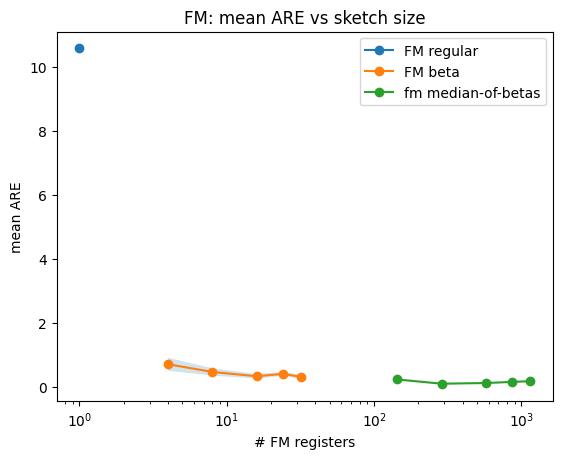

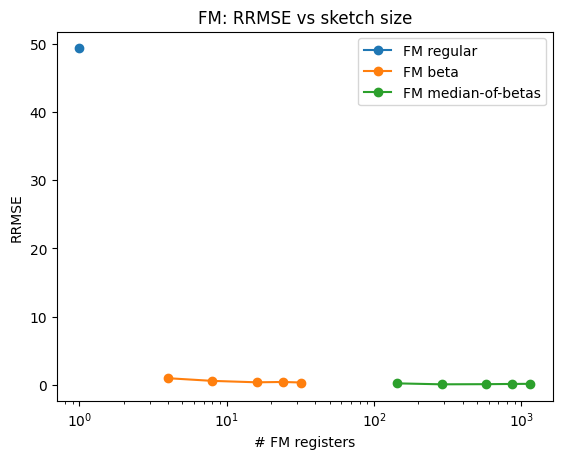

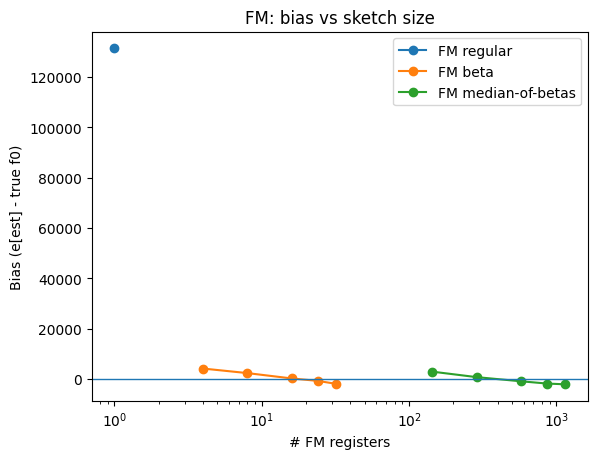

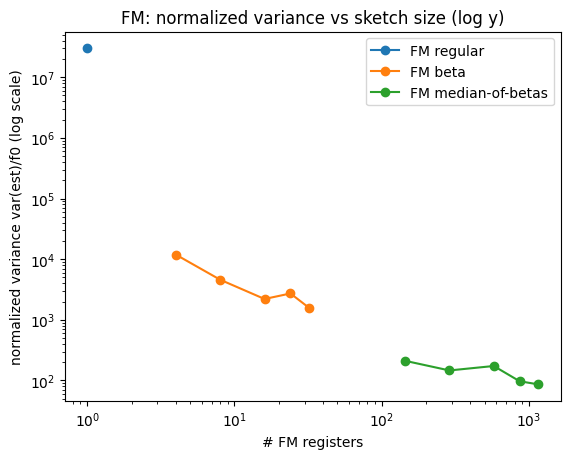

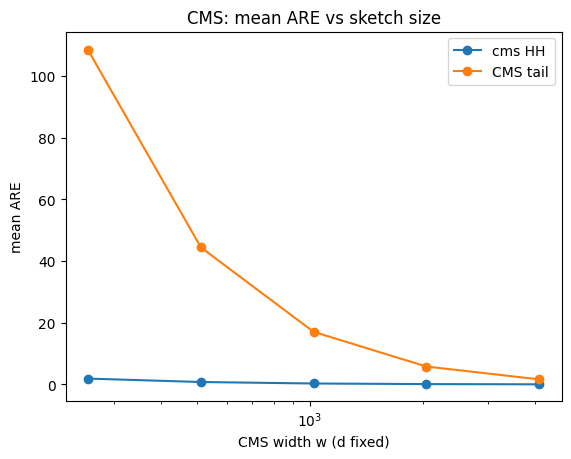

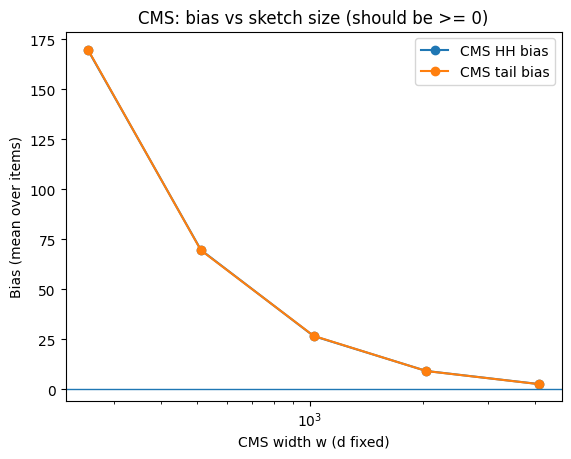

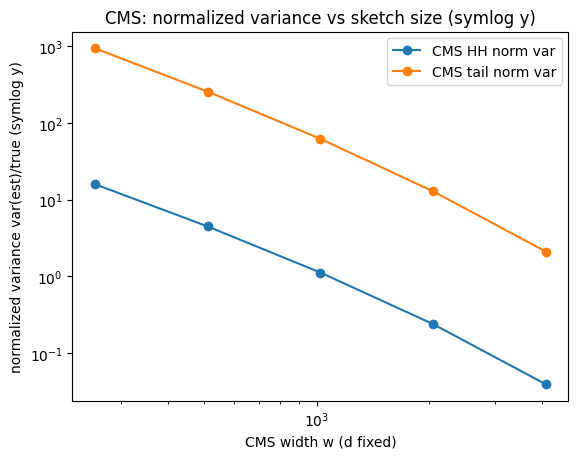

In [ ]:
# define fm x-axis for regular
fm_x_regular = np.array([1], dtype=np.int64)
# define fm x-axis for beta
fm_x_beta = np.array(FM_SIZES, dtype=np.int64)
# define fm x-axis for median-of-betas
fm_x_median = (FM_T * np.array(FM_SIZES, dtype=np.int64))

# define cms x-axis as widths
cms_x = np.array(CMS_WIDTHS, dtype=np.int64)

# plot fm mean are vs registers
plt.figure()
plt.xscale("log")
plt.plot(fm_x_regular, [float(fm_reg_are.mean())], marker="o", label="FM regular")
plt.plot(fm_x_beta, fm_beta_m["mean_are"], marker="o", label="FM beta")
plt.fill_between(fm_x_beta, fm_beta_m["mean_are"] - fm_beta_m["ci_are"], fm_beta_m["mean_are"] + fm_beta_m["ci_are"], alpha=0.2)
plt.plot(fm_x_median, fm_med_m["mean_are"], marker="o", label="fm median-of-betas")
plt.fill_between(fm_x_median, fm_med_m["mean_are"] - fm_med_m["ci_are"], fm_med_m["mean_are"] + fm_med_m["ci_are"], alpha=0.2)
plt.xlabel("# FM registers")
plt.ylabel("mean ARE")
plt.title("FM: mean ARE vs sketch size")
plt.legend()
plt.show()

# plot fm rrmse vs registers
plt.figure()
plt.xscale("log")
plt.plot(fm_x_regular, [fm_reg_rrmse], marker="o", label="FM regular")
plt.plot(fm_x_beta, fm_beta_m["rrmse"], marker="o", label="FM beta")
plt.plot(fm_x_median, fm_med_m["rrmse"], marker="o", label="FM median-of-betas")
plt.xlabel("# FM registers")
plt.ylabel("RRMSE")
plt.title("FM: RRMSE vs sketch size")
plt.legend()
plt.show()

# plot fm bias vs registers
plt.figure()
plt.xscale("log")
plt.plot(fm_x_regular, [fm_reg_bias], marker="o", label="FM regular")
plt.plot(fm_x_beta, fm_beta_m["bias"], marker="o", label="FM beta")
plt.plot(fm_x_median, fm_med_m["bias"], marker="o", label="FM median-of-betas")
plt.axhline(0, linewidth=1)
plt.xlabel("# FM registers")
plt.ylabel("Bias (e[est] - true f0)")
plt.title("FM: bias vs sketch size")
plt.legend()
plt.show()

# plot fm normalized variance vs registers (log y-scale improvement)
plt.figure()
plt.xscale("log")
plt.yscale("log")
plt.plot(fm_x_regular, [max(fm_reg_normvar, np.finfo(np.float64).tiny)], marker="o", label="FM regular")
plt.plot(fm_x_beta, np.maximum(fm_beta_m["normvar"], np.finfo(np.float64).tiny), marker="o", label="FM beta")
plt.plot(fm_x_median, np.maximum(fm_med_m["normvar"], np.finfo(np.float64).tiny), marker="o", label="FM median-of-betas")
plt.xlabel("# FM registers")
plt.ylabel("normalized variance var(est)/f0 (log scale)")
plt.title("FM: normalized variance vs sketch size (log y)")
plt.legend()
plt.show()

# plot cms mean are vs width
plt.figure()
plt.xscale("log")
plt.plot(cms_x, cms_hh_m["mean_are"], marker="o", label="cms HH")
plt.fill_between(cms_x, cms_hh_m["mean_are"] - cms_hh_m["ci_are"], cms_hh_m["mean_are"] + cms_hh_m["ci_are"], alpha=0.2)
plt.plot(cms_x, cms_tail_m["mean_are"], marker="o", label="CMS tail")
plt.fill_between(cms_x, cms_tail_m["mean_are"] - cms_tail_m["ci_are"], cms_tail_m["mean_are"] + cms_tail_m["ci_are"], alpha=0.2)
plt.xlabel("CMS width w (d fixed)")
plt.ylabel("mean ARE")
plt.title("CMS: mean ARE vs sketch size")
plt.legend()
plt.show()

# plot cms bias vs width
plt.figure()
plt.xscale("log")
plt.plot(cms_x, cms_hh_m["mean_bias"], marker="o", label="CMS HH bias")
plt.fill_between(cms_x, cms_hh_m["mean_bias"] - cms_hh_m["ci_bias"], cms_hh_m["mean_bias"] + cms_hh_m["ci_bias"], alpha=0.2)
plt.plot(cms_x, cms_tail_m["mean_bias"], marker="o", label="CMS tail bias")
plt.fill_between(cms_x, cms_tail_m["mean_bias"] - cms_tail_m["ci_bias"], cms_tail_m["mean_bias"] + cms_tail_m["ci_bias"], alpha=0.2)
plt.axhline(0, linewidth=1)
plt.xlabel("CMS width w (d fixed)")
plt.ylabel("Bias (mean over items)")
plt.title("CMS: bias vs sketch size (should be >= 0)")
plt.legend()
plt.show()

# plot cms normalized variance vs width (symlog y-scale improvement)
plt.figure()
plt.xscale("log")
plt.yscale("symlog", linthresh=1e-6)
plt.plot(cms_x, cms_hh_m["normvar"], marker="o", label="CMS HH norm var")
plt.plot(cms_x, cms_tail_m["normvar"], marker="o", label="CMS tail norm var")
plt.xlabel("CMS width w (d fixed)")
plt.ylabel("normalized variance var(est)/true (symlog y)")
plt.title("CMS: normalized variance vs sketch size (symlog y)")
plt.legend()
plt.show()

## 11) Convergence Over Time (Prefix Length)

We plot convergence at checkpoints:
`[1k, 2k, 5k, 10k, 20k, 30k, 50k, 70k, 100k]`.

### FM Convergence
For FM we can update registers only when new distinct IDs appear, so we track new uniques per segment.

### CMS Convergence
For CMS we build sketches incrementally and compare estimates to **prefix ground truth** for the query keys.  
Because some tail keys might not have appeared early, we compute mean ARE only over keys with `true > 0` at that prefix.

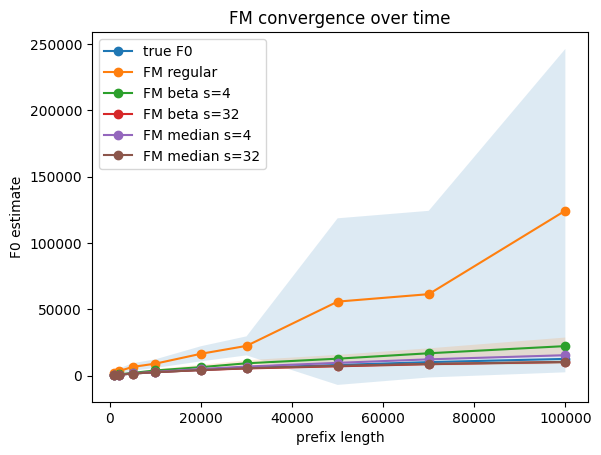

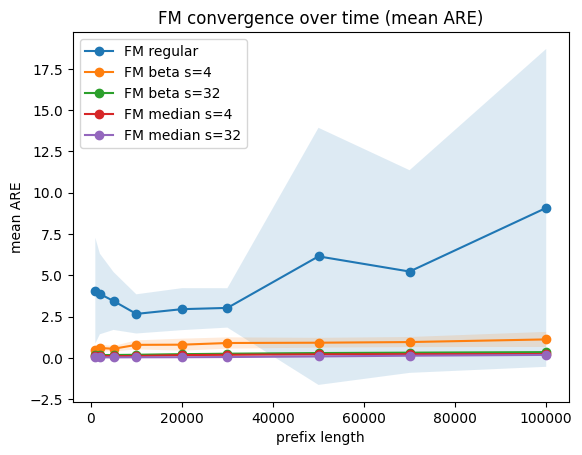

In [ ]:
# define a helper that returns new unique ids introduced in each checkpoint segment
def new_uniques_by_checkpoint(stream_ids_arr: np.ndarray, checkpoints: List[int]) -> List[np.ndarray]:
    # allocate seen array for all ids
    seen = np.zeros(int(stream_ids_arr.max()) + 1, dtype=bool)
    # track previous boundary
    prev = 0
    # initialize output list
    out = []
    # iterate over checkpoints
    for cp in checkpoints:
        # slice segment
        seg = stream_ids_arr[prev:cp]
        # select ids not seen yet
        new = seg[~seen[seg]]
        # update seen and take unique new ids
        if new.size:
            # compute unique new ids
            u = np.unique(new)
            # mark new ids as seen
            seen[u] = True
        else:
            # set empty array if no new ids
            u = np.array([], dtype=np.int64)
        # append new unique ids for this segment
        out.append(u.astype(np.int64))
        # advance prev
        prev = cp
    # return list of new-id arrays
    return out

# compute new unique ids per checkpoint segment
new_uniques_segments = new_uniques_by_checkpoint(stream_ids, CHECKPOINTS)

# define a function that runs fm convergence using incremental distinct updates
def fm_convergence(trials: int, checkpoints: List[int], new_segments: List[np.ndarray], variant: str, s: int = None, t: int = None, seed_offset: int = 50_000) -> np.ndarray:
    # store number of checkpoints
    T = len(checkpoints)
    # determine number of registers for the variant
    if variant == "regular":
        regs = 1
    elif variant == "beta":
        regs = int(s)
    elif variant == "median":
        regs = int(t * s)
    else:
        raise ValueError("unknown fm variant")
    # allocate output matrix (trials x checkpoints)
    ests = np.zeros((trials, T), dtype=np.float64)
    # loop over trials
    for r in range(trials):
        # create per-trial rng
        rng = np.random.default_rng(GLOBAL_SEED + seed_offset + r)
        # generate hash parameters for the chosen variant
        if variant == "regular":
            a, b = gen_ab(rng, 1)
        elif variant == "beta":
            a, b = gen_ab(rng, int(s))
        else:
            a, b = gen_ab(rng, int(t * s))
        # initialize minima registers
        minima = np.ones(regs, dtype=np.float64)
        # loop over checkpoint segments
        for j, new_ids in enumerate(new_segments):
            # update minima only if new ids exist
            if new_ids.size:
                # convert new ids to uint64
                x = new_ids.astype(np.uint64)
                # hash new ids for all registers
                h = (x[:, None] * a[None, :] + b[None, :]).astype(np.uint64)
                # convert hashes to uniform floats
                u = h.astype(np.float64) / TWO64
                # update minima by chunk minima
                minima = np.minimum(minima, u.min(axis=0))
            # clamp minima away from zero
            minima = np.maximum(minima, np.finfo(np.float64).tiny)
            # compute estimate at this checkpoint
            if variant == "regular":
                ests[r, j] = (1.0 / float(minima[0])) - 1.0
            elif variant == "beta":
                ests[r, j] = (1.0 / float(minima.mean())) - 1.0
            else:
                mins = minima.reshape(int(t), int(s))
                z = mins.mean(axis=1)
                group_ests = (1.0 / z) - 1.0
                ests[r, j] = float(np.median(group_ests))
    # return convergence estimates
    return ests

# compute fm convergence series
fm_conv_reg = fm_convergence(TRIALS, CHECKPOINTS, new_uniques_segments, "regular")
fm_conv_beta_s4 = fm_convergence(TRIALS, CHECKPOINTS, new_uniques_segments, "beta", s=4)
fm_conv_beta_s32 = fm_convergence(TRIALS, CHECKPOINTS, new_uniques_segments, "beta", s=32)
fm_conv_med_s4 = fm_convergence(TRIALS, CHECKPOINTS, new_uniques_segments, "median", s=4, t=FM_T)
fm_conv_med_s32 = fm_convergence(TRIALS, CHECKPOINTS, new_uniques_segments, "median", s=32, t=FM_T)

# convert checkpoints to numpy for plotting
x_t = np.array(CHECKPOINTS, dtype=np.int64)

# define a helper that plots mean and 95% ci bands for time-series matrices
def plot_mean_ci_time(mat: np.ndarray, label: str) -> None:
    # compute mean over trials
    mu = mat.mean(axis=0)
    # compute ci half-width
    ci = 1.96 * mat.std(axis=0, ddof=1) / np.sqrt(mat.shape[0])
    # plot mean curve
    plt.plot(x_t, mu, marker="o", label=label)
    # plot ci band
    plt.fill_between(x_t, mu - ci, mu + ci, alpha=0.15)

# plot fm convergence (f0 estimate)
plt.figure()
plt.plot(x_t, true_F0_t, marker="o", label="true F0")
plot_mean_ci_time(fm_conv_reg, "FM regular")
plot_mean_ci_time(fm_conv_beta_s4, "FM beta s=4")
plot_mean_ci_time(fm_conv_beta_s32, "FM beta s=32")
plot_mean_ci_time(fm_conv_med_s4, "FM median s=4")
plot_mean_ci_time(fm_conv_med_s32, "FM median s=32")
plt.xlabel("prefix length")
plt.ylabel("F0 estimate")
plt.title("FM convergence over time")
plt.legend()
plt.show()

# define a helper that computes mean are over time
def mean_are_over_time(est_mat: np.ndarray, true_vals: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    # compute relative errors
    rel = (est_mat - true_vals[None, :]) / true_vals[None, :]
    # compute absolute relative errors
    are = np.abs(rel)
    # compute mean are and ci
    mu = are.mean(axis=0)
    ci = 1.96 * are.std(axis=0, ddof=1) / np.sqrt(est_mat.shape[0])
    # return mean and ci
    return mu, ci

# plot fm convergence (mean are)
plt.figure()
for label, mat in [
    ("FM regular", fm_conv_reg),
    ("FM beta s=4", fm_conv_beta_s4),
    ("FM beta s=32", fm_conv_beta_s32),
    ("FM median s=4", fm_conv_med_s4),
    ("FM median s=32", fm_conv_med_s32),
]:
    mu, ci = mean_are_over_time(mat, true_F0_t.astype(np.float64))
    plt.plot(x_t, mu, marker="o", label=label)
    plt.fill_between(x_t, mu - ci, mu + ci, alpha=0.15)
plt.xlabel("prefix length")
plt.ylabel("mean ARE")
plt.title("FM convergence over time (mean ARE)")
plt.legend()
plt.show()

We can observe that the longer the prefix length is, the more accurate the estimator is.

cms conv trial 10/50
cms conv trial 20/50
cms conv trial 30/50
cms conv trial 40/50
cms conv trial 50/50


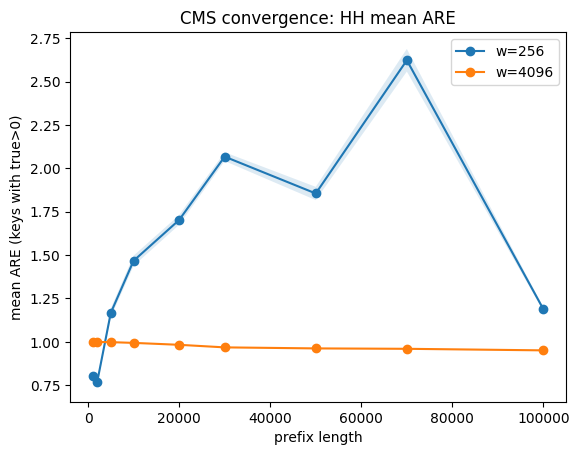

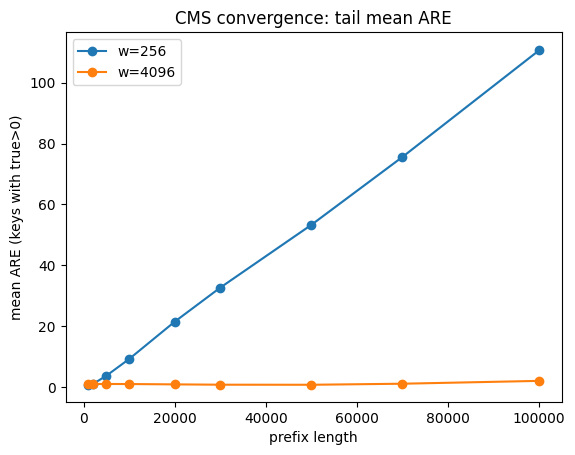

In [ ]:
# define selected cms widths for convergence plots
CMS_CONV_WIDTHS = [256, 4096]

# define a function that runs cms convergence and compares to prefix ground truth for query keys
def cms_convergence(trials: int, checkpoints: List[int], widths: List[int], stream_ids_arr: np.ndarray, top_ids_arr: np.ndarray, tail_ids_arr: np.ndarray, d: int = 5, w_max: int = 4096, seed_offset: int = 80_000) -> Tuple[np.ndarray, np.ndarray]:
    # store number of checkpoints
    T = len(checkpoints)
    # store number of widths
    W = len(widths)
    # allocate output tensors (trials x widths x checkpoints)
    are_hh = np.zeros((trials, W, T), dtype=np.float64)
    are_tail = np.zeros((trials, W, T), dtype=np.float64)
    # convert stream to uint64 for hashing
    x = stream_ids_arr.astype(np.uint64)
    # create mask for max width
    mask_max = np.uint64(w_max - 1)
    # loop over trials
    for r in range(trials):
        # create per-trial rng
        rng = np.random.default_rng(GLOBAL_SEED + seed_offset + r)
        # generate hash params for cms rows
        a_rows, b_rows = gen_ab(rng, d)
        # initialize counts at max width
        counts_max = np.zeros((d, w_max), dtype=np.int64)
        # initialize prefix true counts for the query keys
        true_hh = np.zeros(top_ids_arr.shape[0], dtype=np.int64)
        true_tail = np.zeros(tail_ids_arr.shape[0], dtype=np.int64)
        # track previous checkpoint boundary
        prev = 0
        # loop over checkpoints
        for ti, cp in enumerate(checkpoints):
            # slice current segment
            seg = x[prev:cp]
            # update cms table row by row
            for i in range(d):
                h = (seg * a_rows[i] + b_rows[i]).astype(np.uint64)
                idx = (h & mask_max).astype(np.int64)
                counts_max[i] += np.bincount(idx, minlength=w_max)
            # update prefix true counts for query keys
            seg_i64 = seg.astype(np.int64)
            seg_counts = np.bincount(seg_i64, minlength=F0)
            true_hh = true_hh + seg_counts[top_ids_arr]
            true_tail = true_tail + seg_counts[tail_ids_arr]
            # query sketches for each selected width
            for wi, w in enumerate(widths):
                hh_est = cms_query_from_max(counts_max, a_rows, b_rows, top_ids_arr, w).astype(np.float64)
                tail_est = cms_query_from_max(counts_max, a_rows, b_rows, tail_ids_arr, w).astype(np.float64)
                hh_true = true_hh.astype(np.float64)
                tail_true = true_tail.astype(np.float64)
                hh_mask = hh_true > 0
                tail_mask = tail_true > 0
                if np.any(hh_mask):
                    are_hh[r, wi, ti] = np.abs((hh_est[hh_mask] - hh_true[hh_mask]) / hh_true[hh_mask]).mean()
                else:
                    are_hh[r, wi, ti] = np.nan
                if np.any(tail_mask):
                    are_tail[r, wi, ti] = np.abs((tail_est[tail_mask] - tail_true[tail_mask]) / tail_true[tail_mask]).mean()
                else:
                    are_tail[r, wi, ti] = np.nan
            prev = cp
        if (r + 1) % 10 == 0:
            print(f"cms conv trial {r+1}/{trials}")
    return are_hh, are_tail

# run cms convergence
cms_conv_are_hh, cms_conv_are_tail = cms_convergence(
    TRIALS,
    CHECKPOINTS,
    CMS_CONV_WIDTHS,
    stream_ids,
    topk_ids,
    tail_ids,
    d=CMS_D,
    w_max=CMS_W_MAX,
)

# define a helper to plot cms convergence mean are with ci
def plot_cms_conv(mat: np.ndarray, title: str) -> None:
    plt.figure()
    for wi, w in enumerate(CMS_CONV_WIDTHS):
        series = mat[:, wi, :]
        mu = np.nanmean(series, axis=0)
        sd = np.nanstd(series, axis=0, ddof=1)
        n = np.sum(~np.isnan(series), axis=0)
        ci = 1.96 * sd / np.sqrt(np.maximum(n, 1))
        plt.plot(x_t, mu, marker="o", label=f"w={w}")
        plt.fill_between(x_t, mu - ci, mu + ci, alpha=0.15)
    plt.xlabel("prefix length")
    plt.ylabel("mean ARE (keys with true>0)")
    plt.title(title)
    plt.legend()
    plt.show()

# plot cms convergence for heavy hitters
plot_cms_conv(cms_conv_are_hh, "CMS convergence: HH mean ARE")
# plot cms convergence for tail items
plot_cms_conv(cms_conv_are_tail, "CMS convergence: tail mean ARE")

## 12) Memory and Runtime Proxies

Memory proxies:
- FM regular: 1 float register
- FM beta: `s` float registers
- FM median: `t*s` float registers
- CMS: `d*w` integer counters

Runtime proxies:
- Mean wall-clock per trial/config, using `time.perf_counter()`

In [ ]:
# initialize memory proxy rows
mem_rows = []

# append fm regular memory row
mem_rows.append({"sketch": "fm regular", "params": "1 reg", "count": 1, "bytes": 8})

# append fm beta memory rows
for s in FM_SIZES:
    mem_rows.append({"sketch": "fm beta", "params": f"s={s}", "count": int(s), "bytes": int(s * 8)})

# append fm median memory rows
for s in FM_SIZES:
    regs = int(FM_T * s)
    mem_rows.append({"sketch": "fm median", "params": f"t={FM_T}, s={s}", "count": regs, "bytes": int(regs * 8)})

# append cms memory rows
for w in CMS_WIDTHS:
    counters = int(CMS_D * w)
    mem_rows.append({"sketch": "cms", "params": f"d={CMS_D}, w={w}", "count": counters, "bytes": int(counters * 8)})

# create memory dataframe
mem_df = pd.DataFrame(mem_rows)
# display memory proxy table
mem_df

,sketch,params,count,bytes
0,fm regular,1 reg,1,8
1,fm beta,s=4,4,32
2,fm beta,s=8,8,64
3,fm beta,s=16,16,128
4,fm beta,s=24,24,192
5,fm beta,s=32,32,256
6,fm median,"t=36, s=4",144,1152
7,fm median,"t=36, s=8",288,2304
8,fm median,"t=36, s=16",576,4608
9,fm median,"t=36, s=24",864,6912


In [ ]:
# build runtime summary dictionary
rt_summary = {}

# store fm regular runtime
rt_summary["fm regular mean(s)"] = float(rt_fm_regular.mean())
# store cms build runtime
rt_summary["cms build mean(s)"] = float(rt_cms_build.mean())

# store fm beta runtimes per s
for j, s in enumerate(FM_SIZES):
    rt_summary[f"fm beta s={s} mean(s)"] = float(rt_fm_beta[:, j].mean())

# store fm median runtimes per s
for j, s in enumerate(FM_SIZES):
    rt_summary[f"fm median s={s} mean(s)"] = float(rt_fm_median[:, j].mean())

# store cms query runtimes per width
for j, w in enumerate(CMS_WIDTHS):
    rt_summary[f"cms query w={w} mean(s)"] = float(rt_cms_query[:, j].mean())

# display runtime summary
pd.Series(rt_summary).sort_index()

,0
cms build mean(s),0.004040
cms query w=1024 mean(s),0.000530
cms query w=2048 mean(s),0.000786
cms query w=256 mean(s),0.000477
cms query w=4096 mean(s),0.000422
cms query w=512 mean(s),0.000498
fm beta s=16 mean(s),0.028975
fm beta s=24 mean(s),0.039319
fm beta s=32 mean(s),0.051199
fm beta s=4 mean(s),0.012794


## 13) Conclusions and Analysis

### FM (Distinct Counting / F0 Estimation)
- The **regular FM** estimator is extremely unstable in practice: it uses a *single* register, so rare “unlucky” hash outcomes can make the statistic explode. In our experiments this appears as **very large mean ARE and RRMSE**, **huge positive bias**, and **massive normalized variance**, so it is not practical as a standalone estimator.
- The **FM beta (averaging)** version improves accuracy by averaging `s` independent registers before applying the inversion step. Empirically, increasing `s` produces:
  - **Lower mean ARE and RRMSE**
  - **Bias closer to 0**
  - **Much lower normalized variance**
- The **FM median-of-betas** version is the most robust: taking the median across `t` independent beta estimators suppresses outliers and yields the **lowest errors** and **most stable behavior**, especially in the convergence-over-time plots. The tradeoff is **higher runtime and memory** because it runs many estimators.

- Unbiasedness for FM:
Unbiasedness is expressed by the estimated bias approaching 0 (and its 95% CI overlapping 0) as the number of registers increases, especially for beta and median-of-betas.

### CMS (Frequency Estimation)
- CMS estimates are **never below** the truth (`CMS_est >= f`) because collisions can only increase counters and the query returns the **minimal** estimator. The included sanity check confirms this property in our implementation.
- CMS exhibits **positive bias** due to collisions, and this bias **decreases as width `w` increases**, matching the observed bias-vs-width plots.
- The **tail** query set shows much larger *relative* error than heavy hitters. This is expected because CMS primarily provides an **additive** guarantee:
  $
    \tilde f_x \le f_x + \varepsilon F_1
  $
  For small true frequencies `f_x` (tail items), even a moderate additive overcount translates to a very large relative error:
  $
    \frac{\tilde f_x - f_x}{f_x} \approx \frac{\varepsilon F_1}{f_x}
  $
  Therefore, tail relative errors can be huge unless `w` is large.
- Convergence over time:
  - With small width (e.g., `w=256`), collision effects accumulate as the stream grows, so **tail relative error increases strongly** with prefix length. Regarding HH, in an “idealized” view, CMS has an additive error scale $\varepsilon F_1 \approx \varepsilon n$, and if a heavy hitter’s count grows like $f(x)\approx p_x n$, then the *typical* relative error scale is roughly constant:
$$
\frac{\varepsilon n}{p_x n}=\frac{\varepsilon}{p_x}\approx \frac{2}{w\,p_x}.
$$
So you might expect a relatively flat (or slowly improving) curve over time.

    However, the **observed mean ARE** for heavy hitters can still be **bumpy** for small width (like $w=256$) due to several interacting effects:
    `“Heavy Hitter” Is Defined Globally, But Prefixes Change The Story`
    We select HH keys based on the **final stream** (top-$K$ at $n=100{,}000$).  
    But at an early prefix length $m \ll n$, those same keys may *not yet* be extremely frequent.

    So at a prefix $m$:
    - some “global HH” keys may still have relatively small $f_m(x)$,
    - which makes their relative error $\left|\tilde f_m(x)-f_m(x)\right|/f_m(x)$ much more sensitive.

    Even if the additive collision noise is steady at scale $\varepsilon m$, dividing by a smaller $f_m(x)$ inflates ARE.

    This alone can create non-monotone behavior:
    $$
    \mathrm{ARE}_m(x) \approx \frac{\text{collision noise at }m}{f_m(x)}.
    $$

  - With large width (e.g., `w=4096`), collisions are rarer, so both heavy-hitter and tail errors remain **much more stable** over time.

  
- Unbiasedness for CMS:
  CMS is inherently biased upward, so unbiasedness is not expected; instead, we show bias decreases toward 0 as width w increases.

### Theory vs Practice
- **CMS**: with `d=5`, $\delta = 2^{-5} = 0.03125 $, so success probability is $1-\delta \approx 0.96875$ (≥95%).
- **CMS**: $\varepsilon \approx 2/w$, so the additive bound is $\varepsilon F_1 \approx (2F_1)/w$. This matches the trend that wider sketches yield smaller worst-case error.
- **Bounds are conservative**: empirical errors are often smaller than worst-case guarantees because the theory covers adversarial collision scenarios.

### Final Takeaways
- This project demonstrated how theoretical concepts from the lectures translate into functional, practical implementations.

- **FM regular** is a useful baseline but is too unstable to use in practice.
- **FM beta** provides a strong accuracy improvement with small memory and runtime costs as `s` increases.
- **FM median-of-betas** is the most robust FM variant, but it is slower and uses more registers.
- **CMS** is reliable for heavy hitters and moderate counts (with predictable improvement as width grows), but **tail relative error can be extremely large** at small widths due to the additive nature of its guarantee.

